# DSCI 552 HW 2
   Name: Caitlyn Chan
   GitHub Username: ccaitlynchan
   USC ID: 2717411112

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error


RANDOM_STATE = 42
PREDICTORS = ["AT", "V", "AP", "RH"]
RESPONSE = "PE"

## 1. Combined Cycle Power Plant Data Set

### 1a. data download



In [3]:
df = pd.read_excel("/content/Folds5x2_pp.xlsx", sheet_name=0)
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### 1b. exploring the data

#### 1.b.i. rows & columns

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:", list(df.columns))
print("Missing values:", df.isna().sum().sum())

Rows: 9568
Columns: 5
Column names: ['AT', 'V', 'AP', 'RH', 'PE']
Missing values: 0


The data set has 9568 rows and 5 columns. Each of the rows represents an hour of the power plant running at full load between 2006 and 2011 with each value being the average for that hour. The columns are the variables measured each hour which are ambient temperature, exhaust vacuum, ambient pressure, relative humidity, and net hourly electrical energy output.

#### 1.b.ii Pairwise scatterplots

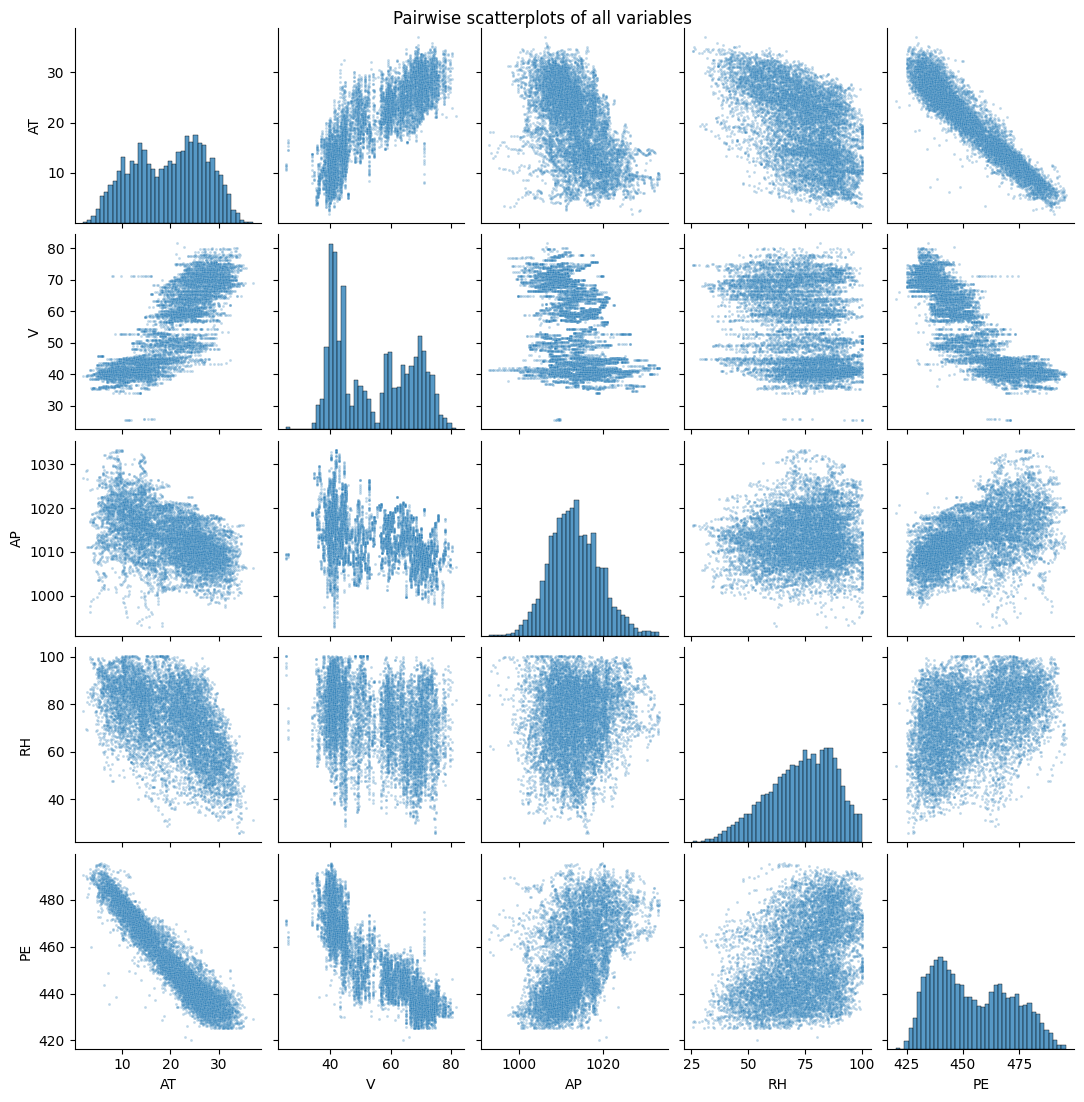

       AT      V     AP     RH     PE
AT  1.000  0.844 -0.508 -0.543 -0.948
V   0.844  1.000 -0.414 -0.312 -0.870
AP -0.508 -0.414  1.000  0.100  0.518
RH -0.543 -0.312  0.100  1.000  0.390
PE -0.948 -0.870  0.518  0.390  1.000


In [5]:
g = sns.pairplot(df, plot_kws={"s": 4, "alpha": 0.3}, diag_kws={"bins": 40}, height=2.2)
g.fig.suptitle("Pairwise scatterplots of all variables", y=1)
plt.show()

print(df.corr().round(3))

Findings:

The strongest relationship is between AT and PE where as temperature goes up, power output goes down. We can see on the graph a negative line(correlation= -0.948). To the right (comparing V to PE), we can also see that V  has a strong negative relationship with PE (= -0.87), but it's noisier and the points are more clustered and variable. AP and RH both have weak positive relationships with PE (=0.52 and = 0.39), demonstrating that neither one predicts output well on its own. For predictors, there is a strong positive correlation between AT and V (= 0.84). This may indicate that  they carry a lot of the same information. RH tends to be lower when AT is higher. AP also tends to be lower when AT is higher (r = −0.51), while AP vs. RH and V vs. RH show no clear pattern. The histograms show that AT and PE each have two peaks. This can likely be attributed to seasonal fluctuations.

#### 1.b.iii summary statistics

In [6]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Min": df.min(),
    "Max": df.max(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
})
summary["IQR"] = summary["Q3"] - summary["Q1"]
summary.round(2)

,Mean,Median,Min,Max,Range,Q1,Q3,IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


### 1c. simple linear regression for each predictor


In [7]:
simple_models = {}
rows = []
for p in PREDICTORS:
    m = smf.ols(f"{RESPONSE} ~ {p}", data=df).fit()
    simple_models[p] = m
    rows.append({"Predictor": p,
                 "Intercept": m.params["Intercept"],
                 "Slope": m.params[p],
                 "Std. error": m.bse[p],
                 "t-stat": m.tvalues[p],
                 "p-value": m.pvalues[p],
                 "R2": m.rsquared})
simple_table = pd.DataFrame(rows).set_index("Predictor")
simple_table.round(4)

,Intercept,Slope,Std. error,t-stat,p-value,R2
Predictor,,,,,,
AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989
V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565
AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688
RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519


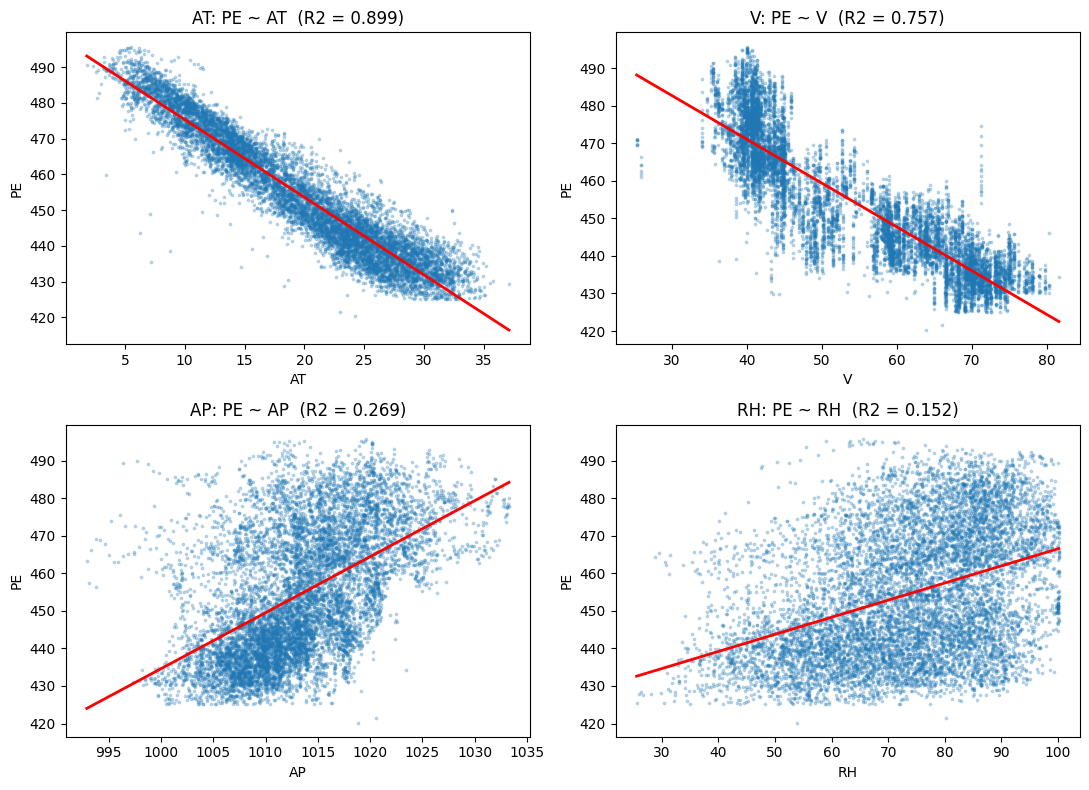

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, p in zip(axes.ravel(), PREDICTORS):
    m = simple_models[p]
    ax.scatter(df[p], df[RESPONSE], s=3, alpha=0.25)
    xs = np.linspace(df[p].min(), df[p].max(), 100)
    ax.plot(xs, m.params["Intercept"] + m.params[p] * xs, color="red", lw=2)
    ax.set_xlabel(p)
    ax.set_ylabel(RESPONSE)
    ax.set_title(f"{p}: PE ~ {p}  (R2 = {m.rsquared:.3f})")
plt.tight_layout()
plt.show()

All four predictors are significantly associated with PE (p < 0.001), so using α = 0.05 we reject H0: B = 0 in each model.

For AT, where slope roughly = −2.17 and R2 = 0.90, each 1 C increase is associated with about 2.17 MW less output. This is the strongest linear relationship.

For V, where slope roughly = −1.17 and R2 = 0.76, there is strong negative relationship. The clustering is in variable, vertical clusters.

For AP, where slope roughly = 1.49, R2 = 0.27 and RH (slope = 0.46, R2 = 0.15), these demonstrate weak positive relationships.

Checking for outliers

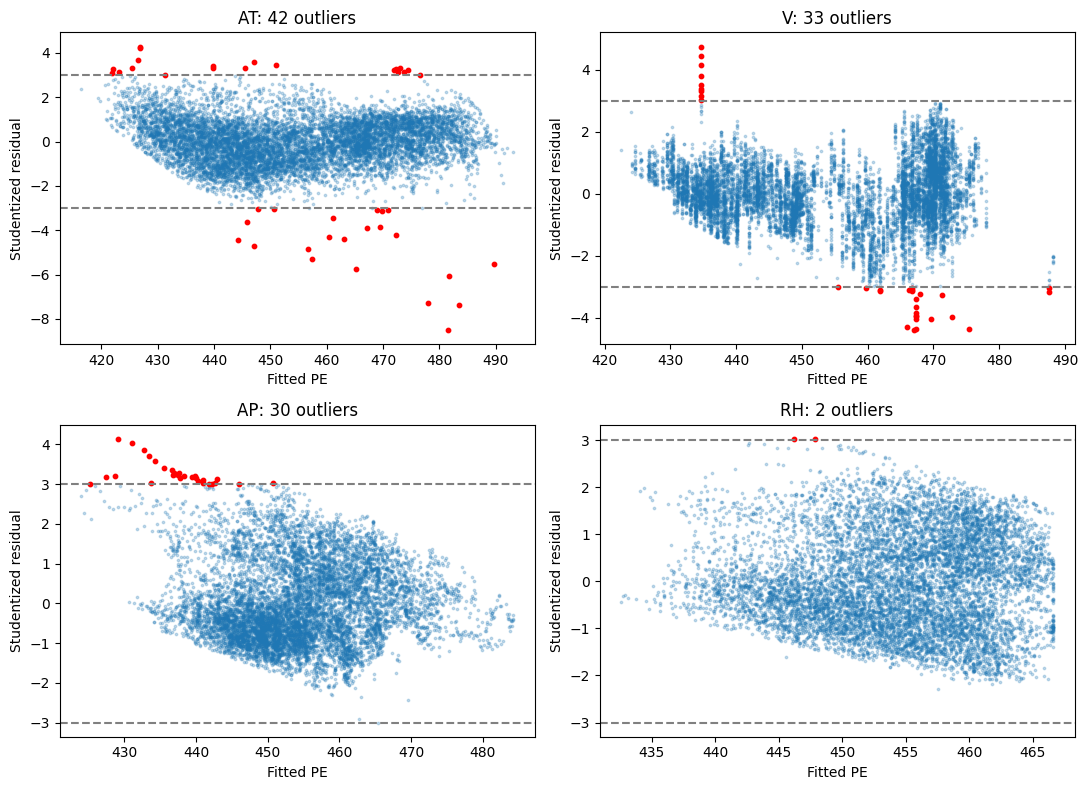

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, p in zip(axes.ravel(), PREDICTORS):
    m = simple_models[p]
    stud = m.get_influence().resid_studentized_external
    out = np.abs(stud) > 3

    ax.scatter(m.fittedvalues, stud, s=3, alpha=0.25)
    ax.scatter(m.fittedvalues[out], stud[out], s=10, color="red")
    ax.axhline(3, color="gray", ls="--")
    ax.axhline(-3, color="gray", ls="--")
    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Studentized residual")
    ax.set_title(f"{p}: {out.sum()} outliers")

plt.tight_layout()
plt.show()

In [10]:
rows = []
for p in PREDICTORS:
    m = simple_models[p]
    stud = m.get_influence().resid_studentized_external
    keep = np.abs(stud) <= 3
    m2 = smf.ols(f"{RESPONSE} ~ {p}", data=df[keep]).fit()

    rows.append({"Predictor": p,
                 "Outliers": (~keep).sum(),
                 "Slope": m.params[p],
                 "Slope (no outliers)": m2.params[p],
                 "R2": m.rsquared,
                 "R2 (no outliers)": m2.rsquared})

pd.DataFrame(rows).set_index("Predictor").round(4)

,Outliers,Slope,Slope (no outliers),R2,R2 (no outliers)
Predictor,,,,,
AT,42,-2.1713,-2.1802,0.8989,0.9064
V,33,-1.1681,-1.1769,0.7565,0.7670
AP,30,1.4899,1.5401,0.2688,0.2864
RH,2,0.4557,0.4564,0.1519,0.1526


From these residual plots, you can see that each model has a pretty small number of points with |studentized residual| > 3. There's 42 out of roughly 9,500 observations and only 2 for RH. As the table above shows, removing them does not change the slopes or R² substantially. These points are also all in reasonable ranges, so I would not remove them.

The residual plots also show a pattern, most noticeably for AT and AP, which means the linear model may not be capturing some of the nonlinearity.

### 1d. multiple regression

In [11]:
full = smf.ols(f"{RESPONSE} ~ AT + V + AP + RH", data=df).fit()
print(full.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        06:11:55   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

As R2 = 0.929, the model fits the data well as the 4 predictors explain about 93% of the variation in PE. When the other predictors are held constant, higher AT, V, and RH are associated with lower output, while AP is associated with slightly higher output. AT has by far the largest effect: each 1C increase lowers output by about 2 MW.

All 4 p-values are below 0.001. Therefore, we reject H0: Bj = 0 for all 4 predictors.


### 1e. simple vs. multiple regression coefficients

    Simple (1c)  Multiple (1d)
AT      -2.1713        -1.9775
V       -1.1681        -0.2339
AP       1.4899         0.0621
RH       0.4557        -0.1581


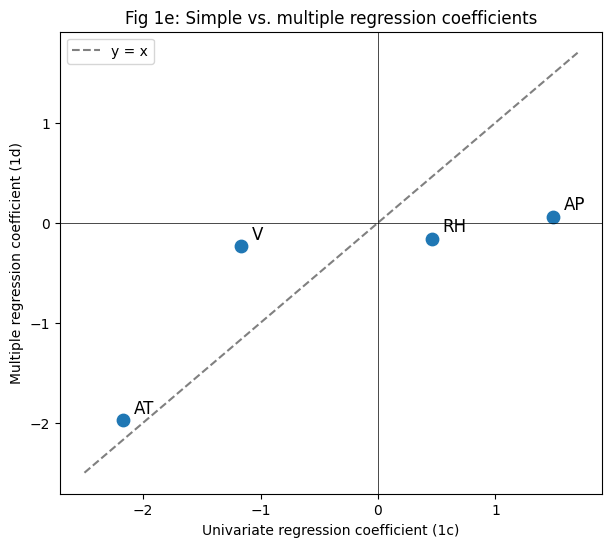

In [12]:
coef_cmp = pd.DataFrame({
    "Simple (1c)": [simple_models[p].params[p] for p in PREDICTORS],
    "Multiple (1d)": [full.params[p] for p in PREDICTORS],
}, index=PREDICTORS)
print(coef_cmp.round(4))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(coef_cmp["Simple (1c)"], coef_cmp["Multiple (1d)"], s=80)
for p in PREDICTORS:
    ax.annotate(p, (coef_cmp.loc[p, "Simple (1c)"], coef_cmp.loc[p, "Multiple (1d)"]),
                textcoords="offset points", xytext=(8, 5), fontsize=12)
lim = [-2.5, 1.7]
ax.plot(lim, lim, ls="--", color="gray", label="y = x")
ax.axhline(0, color="black", lw=0.5); ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Univariate regression coefficient (1c)")
ax.set_ylabel("Multiple regression coefficient (1d)")
ax.set_title("Fig 1e: Simple vs. multiple regression coefficients")
ax.legend(); plt.show()

In this plot we can see that AT is closest to the y = x line, so its coefficient is about the same in the simple regressions (1c) and the multiple regression (1d). The other predictors have weaker effects in 1d than in 1c as their coefficients fall closer to 0. Another noticeable difference is RH's coefficient being negative in multiple regression coefficient but positive in the linear regression coefficient.

### 1f. nonlinear association




In [13]:
rows = []
poly_models = {}
for p in PREDICTORS:
    d = df.assign(x=df[p] - df[p].mean())
    m = smf.ols(f"{RESPONSE} ~ x + I(x**2) + I(x**3)", data=d).fit()
    poly_models[p] = m
    rows.append({"Predictor": p,
                 "p(X2)": m.pvalues["I(x ** 2)"],
                 "p(X3)": m.pvalues["I(x ** 3)"],
                 "R2 linear": simple_models[p].rsquared,
                 "R2 cubic": m.rsquared})
pd.DataFrame(rows).set_index("Predictor").round(4)

,p(X2),p(X3),R2 linear,R2 cubic
Predictor,,,,
AT,0.0000,0.0000,0.8989,0.9119
V,0.0000,0.0137,0.7565,0.7750
AP,0.0000,0.0000,0.2688,0.2975
RH,0.1014,0.0000,0.1519,0.1537


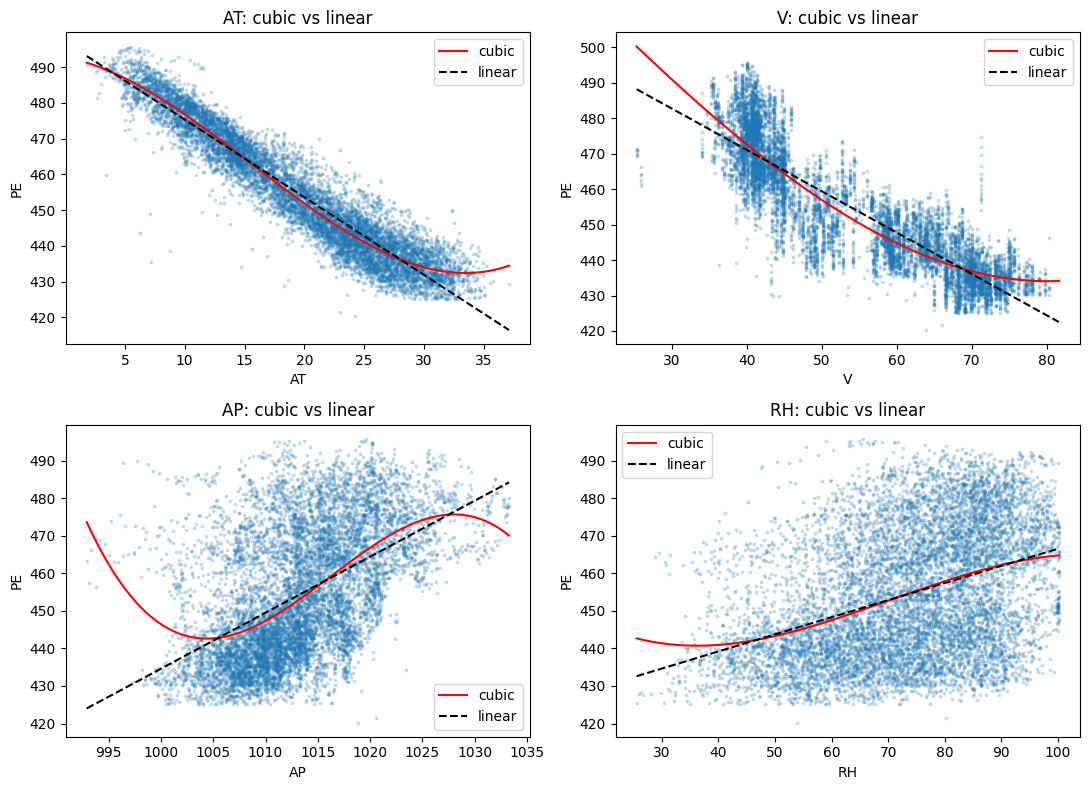

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, p in zip(axes.ravel(), PREDICTORS):
    xs = np.linspace(df[p].min(), df[p].max(), 200)
    ax.scatter(df[p], df[RESPONSE], s=3, alpha=0.2)
    ax.plot(xs, poly_models[p].predict(pd.DataFrame({"x": xs - df[p].mean()})),
            color="red", label="cubic")
    ax.plot(xs, simple_models[p].predict(pd.DataFrame({p: xs})), "k--", label="linear")
    ax.set(xlabel=p, ylabel=RESPONSE, title=f"{p}: cubic vs linear")
    ax.legend()
plt.tight_layout()
plt.show()

There is evidence of nonlinear association for all four predictors because there's at least one of the X2 or X3 terms that is significant at p < 0.05 for each model.

### 1g. interaction terms

In [15]:
inter = smf.ols(f"{RESPONSE} ~ (AT + V + AP + RH)**2", data=df).fit()
print(inter.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        06:11:56   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

Yes, there is evidence of association of interactions of predictors with the response. At p < 0.05, the interactions AT:V, AT:RH, V:AP, and AP:RH are significant. Meanwhile, AT:AP (p = 0.452) and V:RH (p = 0.086) are not.

### 1h. model improvement

In [16]:
train, test = train_test_split(df, train_size=0.7, random_state=RANDOM_STATE)
print("Train size:", len(train), "Test size:", len(test))

def mse_report(model, name):
    return {"Model": name,
            "Train MSE": mean_squared_error(train[RESPONSE], model.predict(train)),
            "Test MSE": mean_squared_error(test[RESPONSE], model.predict(test))}

# model A: linear, all predictors
model_A = smf.ols(f"{RESPONSE} ~ AT + V + AP + RH", data=train).fit()

Train size: 6697 Test size: 2871


In [17]:
# model B: all quadratic + interaction terms, then backward elimination
main = PREDICTORS
quad = [f"I({p} ** 2)" for p in PREDICTORS]
pairs = [f"{a}:{b}" for i, a in enumerate(PREDICTORS) for b in PREDICTORS[i + 1:]]
terms = main + quad + pairs

def vars_in(term):
    return term.replace("I(", "").replace(" ** 2)", "").split(":")

def fit_terms(t):
    return smf.ols(f"{RESPONSE} ~ " + " + ".join(t), data=train).fit()

model_B_full = fit_terms(terms)

current = terms.copy()
while True:
    m = fit_terms(current)
    pvals = m.pvalues.drop("Intercept")
    protected = [t in PREDICTORS and any(t in vars_in(u) for u in current if u != t)
                 for t in pvals.index]
    candidates = pvals[[not pr for pr in protected]]
    if candidates.max() <= 0.05:
        break
    drop = candidates.idxmax()
    print(f"Dropping {drop:12s} (p = {candidates.max():.4f})")
    current.remove(drop)

model_B = m
print("\nfinal terms kept:", current)
print(model_B.summary().tables[1])

Dropping V:RH         (p = 0.8674)
Dropping I(V ** 2)    (p = 0.6077)
Dropping V:AP         (p = 0.3578)

final terms kept: ['AT', 'V', 'AP', 'RH', 'I(AT ** 2)', 'I(AP ** 2)', 'I(RH ** 2)', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7568.5210   1420.561     -5.328      0.000   -1.04e+04   -4783.768
AT            -9.6925      2.290     -4.232      0.000     -14.182      -5.203
V             -0.4604      0.032    -14.362      0.000      -0.523      -0.398
AP            15.7203      2.753      5.711      0.000      10.324      21.117
RH             3.7204      0.974      3.818      0.000       1.810       5.630
I(AT ** 2)     0.0195      0.002      8.112      0.000       0.015       0.024
I(AP ** 2)    -0.0076      0.001     -5.726      0.000      -0.010      -0.005
I(RH ** 2)    -0.0019      0.000     -7.046      0.000      -0.0

In [18]:
results_h = pd.DataFrame([
    mse_report(model_A, "A: Linear (all predictors)"),
    mse_report(model_B_full, "B (before elimination): all quad + interactions"),
    mse_report(model_B, "B (final): after removing insignificant terms"),
]).set_index("Model")
results_h.round(3)

,Train MSE,Test MSE
Model,,
A: Linear (all predictors),20.581,21.240
B (before elimination): all quad + interactions,17.888,18.647
B (final): after removing insignificant terms,17.891,18.660


The model can be improved. Model B, with insignificant terms (V:RH, V^2, and V:AP) removed has lower train and test MSEs than the linear Model A (train: 17.89 vs. 20.58; test: 18.66 vs. 21.24)

### 1i. KNN regression


In [19]:
X_train, X_test = train[PREDICTORS], test[PREDICTORS]
y_train, y_test = train[RESPONSE], test[RESPONSE]

scaler = StandardScaler().fit(X_train)
feature_sets = {
    "Raw": (X_train.values, X_test.values),
    "Normalized": (scaler.transform(X_train), scaler.transform(X_test)),
}

ks = range(1, 101)
knn_results = {}
for name, (A, B) in feature_sets.items():
    tr_err, te_err = [], []
    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k).fit(A, y_train)
        tr_err.append(mean_squared_error(y_train, knn.predict(A)))
        te_err.append(mean_squared_error(y_test, knn.predict(B)))
    knn_results[name] = pd.DataFrame({"k": list(ks), "Train MSE": tr_err, "Test MSE": te_err})

best = pd.DataFrame({name: r.loc[r["Test MSE"].idxmin()] for name, r in knn_results.items()}).T
best["k"] = best["k"].astype(int)
best.round(3)

,k,Train MSE,Test MSE
Raw,5,10.601,15.727
Normalized,4,8.591,14.306


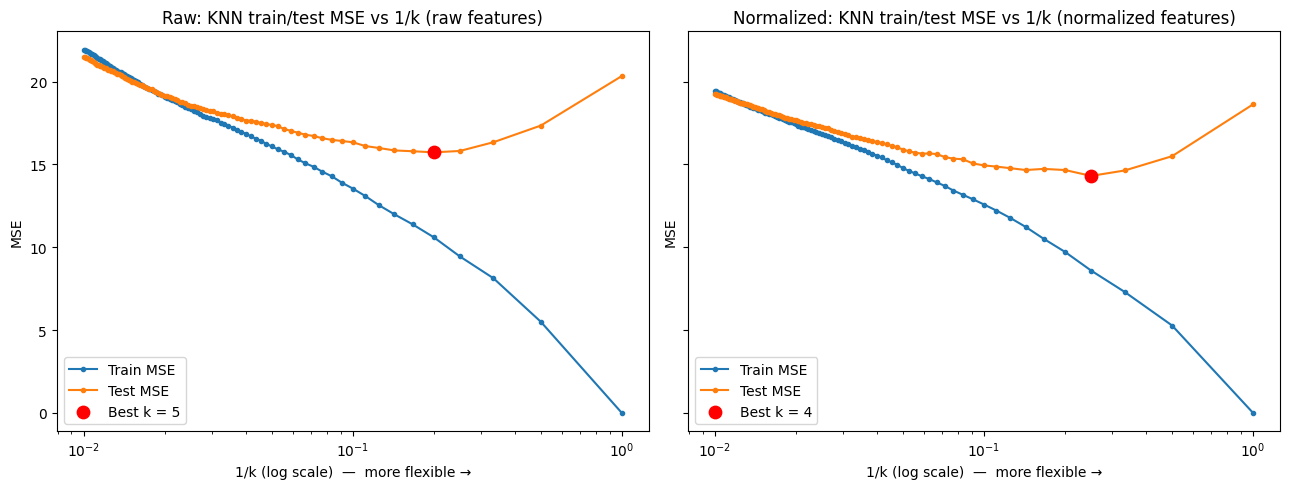

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (name, r) in zip(axes, knn_results.items()):
    inv_k = 1 / r["k"]
    ax.plot(inv_k, r["Train MSE"], marker="o", ms=3, label="Train MSE")
    ax.plot(inv_k, r["Test MSE"], marker="o", ms=3, label="Test MSE")
    b = r.loc[r["Test MSE"].idxmin()]
    ax.scatter(1 / b["k"], b["Test MSE"], color="red", s=80, zorder=5, label=f"Best k = {int(b['k'])}")
    ax.set_xscale("log")
    ax.set_xlabel("1/k (log scale)  —  more flexible →")
    ax.set_ylabel("MSE"); ax.legend()
    ax.set_title(f"{name}: KNN train/test MSE vs 1/k ({name.lower()} features)")
plt.tight_layout(); plt.show()

Raw features: best k = 5 (test MSE ≈ 15.73)
Normalized features: best k = 4 (test MSE ≈ 14.31)

### 1j. KNN vs. best linear model

In [21]:
comparison = pd.DataFrame({
    "Test MSE": [
        results_h.loc["A: Linear (all predictors)", "Test MSE"],
        results_h.loc["B (final): after removing insignificant terms", "Test MSE"],
        best.loc["Raw", "Test MSE"],
        best.loc["Normalized", "Test MSE"],
    ]}, index=["Linear (all predictors)",
               "Linear + interactions/quadratics (best linear)",
               f"KNN raw (k={best.loc['Raw','k']})",
               f"KNN normalized (k={best.loc['Normalized','k']})"])
comparison.round(3)

,Test MSE
Linear (all predictors),21.240
Linear + interactions/quadratics (best linear),18.660
KNN raw (k=5),15.727
KNN normalized (k=4),14.306


The best linear model is Model B from 1h that has a test MSE of 18.66. The best KNN model uses normalized features with k = 4 and has a lower test MSE of 14.31. KNN does better because the relationship between the predictors and PE is nonlinear and has interactions, and KNN can fit any shape while the linear model can only fit the terms we give it. KNN is also likely working well because we have a lot of data and only 4 predictors.

### ISLR Problems

### 2.4.1

(a) The sample size n is extremely large, and the number of predictors p is small.


*   Better- this is because with a large amount of data it's useful to have a flexible method that can fit the shape of f closely without overfitting. The large n helps maintain low variance.

(b) The number of predictors p is extremely large, and the number of observations n is small.
*   Worse- because there will be few observations compared to predictors, a flexible method will overfit, which will result in high variance. An inflexible method's lower variance makes it perform better.

(c) The relationship between the predictors and response is highly non-linear.
*  better- an inflexible method (likely linear) would have high bias since it can't capture its non-linear shape like a flexible method would be able to.

(d) The variance of the error terms, σ² = Var(ε), is extremely high.
*   Worse- because when there is a large amount of noise, a flexible method will try to accommodate it and overfit the random noise rather than the true shape of f. This raises variance. Inflexible methods are less likely to overfit the noise."

### 2.4.7

a.

- Obs 1: √(0² + 3² + 0²) = √9 = 3 | Red
- Obs 2: √(2² + 0² + 0²) = √4 = 2 | Red
- Obs 3: √(0² + 1² + 3²) = √10 ≈ 3.16 | Red
- Obs 4: √(0² + 1² + 2²) = √5 ≈ 2.24 | Green
- Obs 5: √((−1)² + 0² + 1²) = √2 ≈ 1.41 | Green
- Obs 6: √(1² + 1² + 1²) = √3 ≈ 1.73 | Red

b. green: at K = 1, the single closest observation is Obs 5 (d roughly = to 1.41), and it is green.

c. red: at K = 3, the three closest points are Obs 5 (Green), Obs 6 (Red), and Obs 2 (Red). since 2/3 of these are red, red wins.

d. we'd expect the besst value for k to be small since this makes KNN more flexible in order for it to have a more nonlinear shape. a large k takes the average of more points so it makes the boundary smoother/more linear.